# NHL: предсказать успешность команды в следующем сезоне

**Тестовое задание • 100 баллов**

Вы аналитик, которому после окончания сезона нужно оценить перспективы команды
на следующий год. Соберите таблицу с учебного сайта
[Scrape This Site - Hockey Teams](https://www.scrapethissite.com/pages/forms/),
изучите данные и постройте модель классификации.
В работе оцениваются корректность исследования и обоснованность решений.

Ориентир времени: 6-10 часов (знание хоккея не требуется).
Можно обращаться к документации и пользоваться вспомогательными инструментами.
Укажите, чем пользовались; отвечайте за правильность и понимание сданной работы.
Подтверждайте ответы результатами из своего ноутбука.

## Что сдавать

Выполненный IPynb с видимыми результатами и ответами и исходный `data/hockey_raw.csv` разместите на платформе githib.com.
Укажите имя, дату и использованные источники и инструменты в README.

## Что предсказывает модель

Одна строка признаков описывает команду в сезоне `t`.
`target=1`, если доля побед той же команды в сезоне `t+1` строго выше медианной
доли побед всех команд в сезоне `t+1`. В остальных случаях `target=0`.

Медиану считайте по полной исходной таблице будущего года до отбора пар.
В пары включайте одинаковые названия команды с разницей меток сезонов ровно в один год.
Строки без пары исключайте и учитывайте в описании данных.
Будущий `win_rate` и будущая медиана используются для построения target и анализа
готовых прогнозов. Признаки модели должны быть известны после сезона `t`.

## Схема проверки

Делите данные по году целевого сезона:

| Часть | target_year | Назначение |
|---|---|---|
| train | не позднее 2005 | Подготовка данных и обучение |
| validation | 2006-2008 | Сравнение вариантов и выбор решения |
| test | 2009-2011 | Одна итоговая оценка выбранного решения |

Основная метрика: ROC-AUC по вероятности класса 1.
На итоговом этапе также используйте F1 и accuracy при пороге 0.5.
Финальный test используйте после выбора решения на validation.

## Как оценивается работа

| Область | Баллы |
|---|---:|
| Сбор и понимание данных | 15 |
| Построение задачи и корректность проверки | 20 |
| Исследовательский анализ | 20 |
| Модели и эксперименты | 25 |
| Итоговая оценка и анализ ошибок | 15 |
| Ясность и воспроизводимость | 5 |
| **Всего** | **100** |

Ниже перечислены обязательные этапы работы. Внутри них вы самостоятельно выбираете
исследовательские вопросы, графики, признаки, обработку данных, эксперимент и способ
разбора ошибок. Оценивается качество решений, а не совпадение с эталонным маршрутом.
Сложность метода сама по себе не даёт преимущества. Корректный эксперимент может
получить полный балл и в случае отсутствия улучшения.

## Требования к сбору

Итоговая исходная таблица должна иметь столбцы `team`, `year`, `wins`, `losses`,
`ot_losses`, `win_rate`, `goals_for`, `goals_against`, `goal_diff`.
Самостоятельно исследуйте страницу и определите способ получения всей таблицы.

**Автор:** Петров Н.В. 

**Дата:** 05.10.2026

**Использованные источники и инструменты:**
- [Scrape This Site — Hockey Teams](https://www.scrapethissite.com/pages/forms/) —
  источник статистики команд
- Python и Jupyter Notebook в VS Code.
- requests и Beautiful Soup — получение страниц и извлечение ссылок.
- pandas и lxml — извлечение и обработка HTML-таблиц.
- matplotlib — построение графиков.
- scikit-learn — подготовка признаков, обучение моделей и расчёт метрик.
- OpenAI Codex — помощь в подготовке и объяснении
  фрагментов кода, исправлении ошибок и проверке выводов.

In [ ]:
# скачивание необходимых библиотек
%pip install requests pandas numpy matplotlib scikit-learn lxml beautifulsoup4

In [131]:
# Ваши импорты и настройки
import pandas as pd
import numpy as np
from io import StringIO
import requests
from pathlib import Path
from bs4 import BeautifulSoup
from urllib.parse import urlparse, parse_qs
from datetime import datetime, timezone
import time
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score

## Раздел 1. Сбор и понимание данных: 15 баллов

### 1.1. Соберите и сохраните данные

Соберите все страницы сайта в одну таблицу с указанными девятью столбцами.
Сохраните исходную выгрузку в `data/hockey_raw.csv`. Укажите URL и дату сбора,
число обработанных страниц и число строк. Покажите, как проверили,
что сбор не ограничился первой страницей и при повторном анализе можно читать CSV.

In [132]:
# 1.1. Ваш код
# Добавьте ячейки при необходимости.
url = "https://www.scrapethissite.com/pages/forms/"
CSV_PATH = Path("data/hockey_raw.csv")

# предварительный просмотр одной страницы
response = requests.get(url, params={"page_num": 1}, timeout=30)

response.raise_for_status()
tables = pd.read_html(StringIO(response.text))
df_page = tables[0]
display(df_page.head())
print("Строк на странице:", len(df_page))

,Team Name,Year,Wins,Losses,OT Losses,Win %,Goals For (GF),Goals Against (GA),+ / -
0,Boston Bruins,1990,44,24,NaN,0.550,299,264,35
1,Buffalo Sabres,1990,31,30,NaN,0.388,292,278,14
2,Calgary Flames,1990,46,26,NaN,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,NaN,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,NaN,0.425,273,298,-25


Строк на странице: 25


In [133]:
soup = BeautifulSoup(response.text, "html.parser")
page_numbers = {1}

# находим ссылки, содержащие параметр page_num
for link in soup.find_all("a", href=True):
    parameters = parse_qs(urlparse(link["href"]).query)

    if "page_num" in parameters:
        page_numbers.add(int(parameters["page_num"][0]))

page_numbers = sorted(page_numbers)
print("Номера страниц:", page_numbers)
print("Количество страниц в навигации:", len(page_numbers))

Номера страниц: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Количество страниц в навигации: 24


Выполняем требования:
1. Собираем дату
2. Загружаем таблицу с данными сайта с использованием функций из подключенных библиотек

In [134]:
collected_at = datetime.now(timezone.utc).isoformat(timespec="seconds") # время скачивания

all_tables = []
collection_log = []

for page_num in page_numbers:
    response = requests.get(url, params={"page_num":page_num}, timeout=30)
    response.raise_for_status()
    table = pd.read_html(StringIO(response.text), match="Team Name")[0]
    if table.empty:
        raise ValueError(f'{page_num} страница не содержит строк')
    for prev_table in all_tables:
        if table.equals(prev_table):
            raise ValueError("f{page_num} повторяет уже загруженную таблицу")
    all_tables.append(table)
    collection_log.append({"page": page_num, "rows": len(table)})
    print(f"Страница {page_num}: {len(table)} строк")
    time.sleep(0.6)


df_raw = pd.concat(all_tables, ignore_index=True)
collection_log = pd.DataFrame(collection_log)

print(f"\nВсего собрано: {len(df_raw)} строк")


Страница 1: 25 строк
Страница 2: 25 строк
Страница 3: 25 строк
Страница 4: 25 строк
Страница 5: 25 строк
Страница 6: 25 строк
Страница 7: 25 строк
Страница 8: 25 строк
Страница 9: 25 строк
Страница 10: 25 строк
Страница 11: 25 строк
Страница 12: 25 строк
Страница 13: 25 строк
Страница 14: 25 строк
Страница 15: 25 строк
Страница 16: 25 строк
Страница 17: 25 строк
Страница 18: 25 строк
Страница 19: 25 строк
Страница 20: 25 строк
Страница 21: 25 строк
Страница 22: 25 строк
Страница 23: 25 строк
Страница 24: 7 строк

Всего собрано: 582 строк


In [135]:
column_names = {
    "Team Name": "team",
    "Year": "year",
    "Wins": "wins",
    "Losses": "losses",
    "OT Losses": "ot_losses",
    "Win %": "win_rate",
    "Goals For (GF)": "goals_for",
    "Goals Against (GA)": "goals_against",
    "+ / -": "goal_diff",
} # переименовываем столбцы

df_raw.columns = [
    " ".join(str(column).split())
    for column in df_raw.columns
]
df_raw = df_raw.rename(columns=column_names)
df_raw = df_raw[list(column_names.values())]
assert collection_log["page"].tolist() == page_numbers
assert len(all_tables) > 1
assert len(df_raw) > len(all_tables[0])
assert len(df_raw) == collection_log["rows"].sum()

# получены требуемые девять столбцов
assert df_raw.shape[1] == 9

display(collection_log)
display(df_raw.head())
display(df_raw.tail())

print("Проверки сбора пройдены")

,page,rows
0,1,25
1,2,25
2,3,25
3,4,25
4,5,25
5,6,25
6,7,25
7,8,25
8,9,25
9,10,25


,team,year,wins,losses,ot_losses,win_rate,goals_for,goals_against,goal_diff
0,Boston Bruins,1990,44,24,NaN,0.550,299,264,35
1,Buffalo Sabres,1990,31,30,NaN,0.388,292,278,14
2,Calgary Flames,1990,46,26,NaN,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,NaN,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,NaN,0.425,273,298,-25


,team,year,wins,losses,ot_losses,win_rate,goals_for,goals_against,goal_diff
577,Tampa Bay Lightning,2011,38,36,8.0,0.463,235,281,-46
578,Toronto Maple Leafs,2011,35,37,10.0,0.427,231,264,-33
579,Vancouver Canucks,2011,51,22,9.0,0.622,249,198,51
580,Washington Capitals,2011,42,32,8.0,0.512,222,230,-8
581,Winnipeg Jets,2011,37,35,10.0,0.451,225,246,-21


Проверки сбора пройдены


In [136]:
CSV_PATH = Path("data/hockey_raw.csv")
CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
df_raw.to_csv(CSV_PATH, index=False, encoding="utf-8")
df_loaded = pd.read_csv(CSV_PATH)
pd.testing.assert_frame_equal(
    df_raw,
    df_loaded,
    check_dtype=False,
)

print("CSV сохранён, проверка чтения пройдена.")
print("Путь:", CSV_PATH.resolve())
print("URL:", url)
print("Дата и время сбора (UTC):", collected_at)
print("Обработано страниц:", len(collection_log))
print("Число строк:", len(df_loaded))
print("Число столбцов:", df_loaded.shape[1])

CSV сохранён, проверка чтения пройдена.
Путь: C:\Users\nikpe\Desktop\Astra_Testing\data\hockey_raw.csv
URL: https://www.scrapethissite.com/pages/forms/
Дата и время сбора (UTC): 2026-10-05T14:24:06+00:00
Обработано страниц: 24
Число строк: 582
Число столбцов: 9


In [137]:
print(
    f"Данные собраны с {url}\n"
    f"Дата и время сбора (UTC): {collected_at}.\n"
    f"Обработано страниц: {len(collection_log)}; "
    f"получено строк: {len(df_raw)}, столбцов: {df_raw.shape[1]}.\n"
    "Исходная таблица сохранена в data/hockey_raw.csv.\n"
    "Число строк по каждой странице показано в журнале collection_log. "
    "Проверено, что обработаны все найденные номера страниц, "
    "таблицы разных страниц не совпадают, а число строк после "
    "объединения равно сумме строк отдельных страниц.\n"
    "CSV прочитан обратно, совпадение с исходной таблицей "
    "проверено через pd.testing.assert_frame_equal."
)

Данные собраны с https://www.scrapethissite.com/pages/forms/
Дата и время сбора (UTC): 2026-10-05T14:24:06+00:00.
Обработано страниц: 24; получено строк: 582, столбцов: 9.
Исходная таблица сохранена в data/hockey_raw.csv.
Число строк по каждой странице показано в журнале collection_log. Проверено, что обработаны все найденные номера страниц, таблицы разных страниц не совпадают, а число строк после объединения равно сумме строк отдельных страниц.
CSV прочитан обратно, совпадение с исходной таблицей проверено через pd.testing.assert_frame_equal.


**Ответ 1.1:**

По ходу работы была выполнена выгрузка данных с сайта, обработка данных, проверки и сохранение в файл формата CSV. 

**ВЫВОДЫ:**

1. Данные собраны с https://www.scrapethissite.com/pages/forms/
2. Дата и время сбора (UTC): 2026-10-03T19:31:57+00:00.
3. Обработано страниц: 24; получено строк: 582, столбцов: 9.
4. Исходная таблица сохранена в data/hockey_raw.csv.
5. Число строк по каждой странице показано в журнале collection_log. Проверено, что обработаны все найденные номера страниц, таблицы разных страниц не совпадают, а число строк после объединения равно сумме строк отдельных страниц.
6. CSV прочитан обратно, совпадение с исходной таблицей проверено через pd.testing.assert_frame_equal.

### 1.2. Проверьте качество таблицы

Изучите типы, пропуски и уникальность пары команда-год.
Добавьте не менее двух проверок согласованности, которые считаете важными
для последующего анализа. Покажите найденные особенности и обоснуйте
решения по их обработке. Сами проверки и способ представления результата выберите самостоятельно.

In [138]:
# 1.2. Ваш код
# Добавьте ячейки при необходимости.
df_loaded.head() # еще раз посмотрим на первые строки в таблице

,team,year,wins,losses,ot_losses,win_rate,goals_for,goals_against,goal_diff
0,Boston Bruins,1990,44,24,NaN,0.550,299,264,35
1,Buffalo Sabres,1990,31,30,NaN,0.388,292,278,14
2,Calgary Flames,1990,46,26,NaN,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,NaN,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,NaN,0.425,273,298,-25


In [139]:
print(f"Типы: \n{df_loaded.dtypes}")
print('\n')
print(f"Пропуски (всего): {df_loaded.isna().sum().sum()}")
print('\n')
print(f"Пропуски по столбцам: \n{df_loaded.isna().sum()}")

Типы: 
team                 str
year               int64
wins               int64
losses             int64
ot_losses        float64
win_rate         float64
goals_for          int64
goals_against      int64
goal_diff          int64
dtype: object


Пропуски (всего): 224


Пропуски по столбцам: 
team               0
year               0
wins               0
losses             0
ot_losses        224
win_rate           0
goals_for          0
goals_against      0
goal_diff          0
dtype: int64


##### В ходе предварительного анализа, получаем, что пропуски содержатся только в столбце ot_losses.

##### Сделаем  **_дополнительные_** проверки:

In [140]:
# проверка на уникальность "команда - год"
# это значит, что каждой команде в конкретном сезоне соответствует 1 строка
duplicate_mask = df_loaded.duplicated(subset=["team", "year"], keep=False)
print("Строк с повторяющейся парой команда–год:", duplicate_mask.sum())

Строк с повторяющейся парой команда–год: 0


In [141]:
# проверка на то, что в разнице голов стоит корректное значение
bad_goal_diff = (df_loaded["goal_diff"] != df_loaded["goals_for"] - df_loaded["goals_against"])
print("Строк с неверной разницей голов:", bad_goal_diff.sum())

Строк с неверной разницей голов: 0


In [142]:
# проверка на корректность числа побед (коэф. должен быть в диапазоне от 0 до 1)
bad_win_rate = ~df_loaded["win_rate"].between(0, 1)
count_columns = ["wins", "losses", "ot_losses", "goals_for", "goals_against"]
counts = df_loaded[count_columns]
bad_counts = (counts.notna() & ((counts < 0) | (counts % 1 != 0))).any(axis=1)
print("Строк с win_rate вне диапазона [0, 1]:", bad_win_rate.sum())
print("Строк с недопустимыми счётчиками:", bad_counts.sum())

Строк с win_rate вне диапазона [0, 1]: 0
Строк с недопустимыми счётчиками: 0


Дополнительные проверка не выявили аномалий. Посмотрим, как распределены пропуски в столбце **ot_losses**:

In [143]:
missing_by_year = (df_loaded.assign(ot_missing = df_loaded["ot_losses"].isna()).groupby("year").agg(total_rows = ("team", "size"),missing_ot_losses=("ot_missing", "sum")))
missing_by_year["missing_percent"] = (100 * missing_by_year["missing_ot_losses"] / missing_by_year["total_rows"]).round(1)
display(missing_by_year)

,total_rows,missing_ot_losses,missing_percent
year,,,
1990,21,21,100.0
1991,22,22,100.0
1992,24,24,100.0
1993,26,26,100.0
1994,26,26,100.0
1995,26,26,100.0
1996,26,26,100.0
1997,26,26,100.0
1998,27,27,100.0


In [144]:
# дополнительно посмотрим отстутствующие года
years = sorted(df_loaded["year"].unique())
missing_years = sorted(set(range(min(years), max(years) + 1)) - set(years))

print("Диапазон лет:", min(years), "–", max(years))
print("Отсутствующие годы внутри диапазона:", missing_years)

Диапазон лет: 1990 – 2011
Отсутствующие годы внутри диапазона: [2004]


**Ответ 1.2:**

По ходу анализа выгруженных данных получили, что пропуски присутствуют только в столбце **ot_losses**. Помимо этого, пропуски присутствуют только с **1990** по **1998** года - данная статистика там отсутствует. Я решил, что оставлю пропуски, так как остальные данные полностью заполнены, а замена нулями или, например, средним будет некорректна. Также, было выявлено, что в статистике отсутствует полностью **2004** год. Другие проверки на корректность также были осуществлены, но аномалий выявлено не было.

## Раздел 2. Построение задачи и корректность проверки: 20 баллов

### 2.1. Постройте target

Соедините строку команды в сезоне `t` с той же командой ровно в сезоне `t+1`
и постройте target по определению задания. Покажите число полученных пар,
число и годы исключённых строк, а также число случаев равенства будущей медиане.
Проверьте расчёт вручную минимум на двух содержательно разных примерах.

Посчитаем медиану каждого сезона

In [145]:
# 2.1. Ваш код
# Добавьте ячейки при необходимости.
source = df_loaded.copy() # будем работать с копией для построения таргета
year_medians = (
    source.groupby("year")["win_rate"]
    .median()
    .rename("future_median")
    .reset_index()
    .rename(columns={"year": "target_year"})
)
display(year_medians)

,target_year,future_median
0,1990,0.4250
1,1991,0.4440
2,1992,0.4760
3,1993,0.4640
4,1994,0.4275
5,1995,0.4330
6,1996,0.4270
7,1997,0.4270
8,1998,0.4150
9,1999,0.4390


Соединяем текущий сезон с будущим

In [146]:
# текущий результат команды
current = source.copy()
current["target_year"] = current["year"] + 1

# результат той же команды в будущем сезоне
future = source[["team", "year", "win_rate"]].rename(columns={"year": "target_year", "win_rate": "future_win_rate"})

# присоединяем future к current (left join)
joined = current.merge(future,on=["team", "target_year"],how="left",validate="one_to_one",indicator=True) 

# добавляем медиану будущего сезона
joined = joined.merge(year_medians, on="target_year", how="left", validate="many_to_one")

# отдельно сохраняем строки без следующего сезона
excluded = joined.loc[joined["_merge"] == "left_only"].copy()

# для обучения задачи оставляем только найденные пары
pairs = (joined.loc[joined["_merge"] == "both"].drop(columns="_merge").copy())
assert pairs["future_median"].notna().all()
pairs["target"] = (pairs["future_win_rate"] > pairs["future_median"]).astype(int)

display(pairs[["team", "year", "win_rate", "target_year", "future_win_rate", "future_median", "target"]].head(10))

,team,year,win_rate,target_year,future_win_rate,future_median,target
0,Boston Bruins,1990,0.550,1991,0.450,0.444,1
1,Buffalo Sabres,1990,0.388,1991,0.388,0.444,0
2,Calgary Flames,1990,0.575,1991,0.388,0.444,0
3,Chicago Blackhawks,1990,0.613,1991,0.450,0.444,1
4,Detroit Red Wings,1990,0.425,1991,0.537,0.444,1
5,Edmonton Oilers,1990,0.463,1991,0.450,0.444,1
6,Hartford Whalers,1990,0.388,1991,0.325,0.444,0
7,Los Angeles Kings,1990,0.575,1991,0.438,0.444,0
8,Minnesota North Stars,1990,0.338,1991,0.400,0.444,0
9,Montreal Canadiens,1990,0.487,1991,0.512,0.444,1


Таблица была сформирована, а теперь покажем какие исключенные строки и не найденные пары, а также равенства медиане

In [147]:
available_years = set(source['year'])

excluded["reason"] = excluded["target_year"].apply(lambda year: ("Будущий год отсутствует в исходной таблице" if year not in available_years else "В будущем году нет команды с тем же названием"))
print("Исходных строк:", len(source))
print("Получено пар:", len(pairs))
print("Исключено строк без пары:", len(excluded))

print("\nИсключённые строки по исходному и будущему году:")
display(excluded.groupby(["year", "target_year", "reason"]).size().reset_index(name="excluded_rows"))

print("Список исключённых строк:")
display(excluded[["team", "year", "target_year", "reason"]].sort_values(["year", "team"]))

equal_median = (pairs["future_win_rate"] == pairs["future_median"])
print("Случаев равенства будущей медиане среди пар:", equal_median.sum())

display(pairs.loc[equal_median,["team", "year", "target_year","future_win_rate", "future_median", "target"]])

# проверки построенной таблицы
assert len(source) == len(pairs) + len(excluded)
assert (pairs["target_year"] == pairs["year"] + 1).all()
assert not pairs.duplicated(["team", "year"]).any()
assert pairs.loc[equal_median, "target"].eq(0).all()

Исходных строк: 582
Получено пар: 516
Исключено строк без пары: 66

Исключённые строки по исходному и будущему году:


,year,target_year,reason,excluded_rows
0,1992,1993,В будущем году нет команды с тем же названием,1
1,1994,1995,В будущем году нет команды с тем же названием,1
2,1995,1996,В будущем году нет команды с тем же названием,1
3,1996,1997,В будущем году нет команды с тем же названием,1
4,2003,2004,Будущий год отсутствует в исходной таблице,30
5,2005,2006,В будущем году нет команды с тем же названием,1
6,2010,2011,В будущем году нет команды с тем же названием,1
7,2011,2012,Будущий год отсутствует в исходной таблице,30


Список исключённых строк:


,team,year,target_year,reason
51,Minnesota North Stars,1992,1993,В будущем году нет команды с тем же названием
111,Quebec Nordiques,1994,1995,В будущем году нет команды с тем же названием
144,Winnipeg Jets,1995,1996,В будущем году нет команды с тем же названием
155,Hartford Whalers,1996,1997,В будущем году нет команды с тем же названием
343,Atlanta Thrashers,2003,2004,Будущий год отсутствует в исходной таблице
...,...,...,...,...
577,Tampa Bay Lightning,2011,2012,Будущий год отсутствует в исходной таблице
578,Toronto Maple Leafs,2011,2012,Будущий год отсутствует в исходной таблице
579,Vancouver Canucks,2011,2012,Будущий год отсутствует в исходной таблице
580,Washington Capitals,2011,2012,Будущий год отсутствует в исходной таблице


Случаев равенства будущей медиане среди пар: 23


,team,year,target_year,future_win_rate,future_median,target
31,New Jersey Devils,1991,1992,0.476,0.476,0
32,New York Islanders,1991,1992,0.476,0.476,0
42,Winnipeg Jets,1991,1992,0.476,0.476,0
46,Chicago Blackhawks,1992,1993,0.464,0.464,0
65,Washington Capitals,1992,1993,0.464,0.464,0
128,Florida Panthers,1995,1996,0.427,0.427,0
142,Vancouver Canucks,1995,1996,0.427,0.427,0
153,Edmonton Oilers,1996,1997,0.427,0.427,0
163,Phoenix Coyotes,1996,1997,0.427,0.427,0
175,Carolina Hurricanes,1997,1998,0.415,0.415,0


А теперь проверим 2 примера с рассчетом медиан, в одной где **target = 1**, а вторую, где **target = 0**

In [148]:
equal_median[equal_median].sum()

np.int64(23)

In [149]:
positive_example = pairs.loc[pairs["target"] == 1].iloc[0]
negative_example = pairs.loc[equal_median].iloc[0]

for example in [positive_example, negative_example]:
    team = example["team"]
    year = int(example["year"])
    next_year = year + 1

    # все доли побед будущего года - до отбора пар
    rates = sorted(
        source.loc[source["year"] == next_year, "win_rate"].tolist()
    )

    n = len(rates)
    middle = n // 2
    # считаем медиану явно без pandas.median()
    if n % 2 == 0:
        left = rates[middle - 1]
        right = rates[middle]
        manual_median = (left + right) / 2
        calculation = f"({left} + {right}) / 2 = {manual_median}"
    else:
        manual_median = rates[middle]
        calculation = f"центральное значение = {manual_median}"

    actual_future_rate = source.loc[
        (source["team"] == team) & (source["year"] == next_year),
        "win_rate",
    ].iloc[0]

    manual_target = int(actual_future_rate > manual_median)

    print(f"\nКоманда: {team}, переход {year} → {next_year}")
    print(f"Команд в будущем сезоне: {n}")
    print(f"Расчёт медианы: {calculation}")
    print(f"Доля побед команды в будущем сезоне: {actual_future_rate}")
    print(
        f"Проверяем: {actual_future_rate} > {manual_median}"
        f" -> {actual_future_rate > manual_median}"
    )
    print(f"Target вручную: {manual_target}")
    print(f"Target в таблице: {int(example['target'])}")

    assert actual_future_rate == example["future_win_rate"]
    assert abs(manual_median - example["future_median"]) < 1e-12
    assert manual_target == example["target"]


Команда: Boston Bruins, переход 1990 → 1991
Команд в будущем сезоне: 22
Расчёт медианы: (0.438 + 0.45) / 2 = 0.444
Доля побед команды в будущем сезоне: 0.45
Проверяем: 0.45 > 0.444 -> True
Target вручную: 1
Target в таблице: 1

Команда: New Jersey Devils, переход 1991 → 1992
Команд в будущем сезоне: 24
Расчёт медианы: (0.476 + 0.476) / 2 = 0.476
Доля побед команды в будущем сезоне: 0.476
Проверяем: 0.476 > 0.476 -> False
Target вручную: 0
Target в таблице: 0


Выводы для итога по пункту 2.1:

In [150]:
print(f"Исходные строки: {len(source)}\n",
      f"Получено пар: {len(pairs)}\n",
      f"Исключено строк из пары: {len(excluded)}\n",
      f"Случаев равенства медиане среди пар: {equal_median.sum()}")

Исходные строки: 582
 Получено пар: 516
 Исключено строк из пары: 66
 Случаев равенства медиане среди пар: 23


**Ответ 2.1:**

Таким образом для построения таргета мы получили следующие данные:
1. Получено пар: 516
2. Исключено строк из пары: 66
3. Случаев равенства медиане среди пар: 23

Таблица **pairs** станет основой для дальнейшей работы. Помимо этого, была воспроизведена ручная проверка медианы, которая совпала с табличными значениями, что означает, что **target** был составлен корректно.

### 2.2. Подготовьте временную проверку

Разделите пары на train, validation и test по заданным границам target_year.
Покажите для каждой части фактические годы, размер и долю класса 1.
Назовите минимум два столбца, которые появились при построении target,
но недоступны модели в момент прогноза. Объясните, почему случайное перемешивание
строк отвечало бы на другой вопрос, чем выбранная временная схема.

Разделяем пары на **train**, **validation** и **test**:

In [151]:
pairs.head()

,team,year,wins,losses,ot_losses,win_rate,goals_for,goals_against,goal_diff,target_year,future_win_rate,future_median,target
0,Boston Bruins,1990,44,24,NaN,0.550,299,264,35,1991,0.450,0.444,1
1,Buffalo Sabres,1990,31,30,NaN,0.388,292,278,14,1991,0.388,0.444,0
2,Calgary Flames,1990,46,26,NaN,0.575,344,263,81,1991,0.388,0.444,0
3,Chicago Blackhawks,1990,49,23,NaN,0.613,284,211,73,1991,0.450,0.444,1
4,Detroit Red Wings,1990,34,38,NaN,0.425,273,298,-25,1991,0.537,0.444,1


In [152]:
# 2.2. Ваш код
# Добавьте ячейки при необходимости.
train = pairs.loc[pairs["target_year"] <= 2005].copy()
validation = pairs.loc[pairs['target_year'].between(2006, 2008)].copy()
test = pairs.loc[pairs['target_year'].between(2009, 2011)].copy()

Фактические годы, размер и доля класса 1:

In [153]:
parts = {"train":train, "test":test, "validation":validation}
sum_rows = []
for name, data in parts.items():
    sum_rows.append({
        "part":name,
        "feature_years": sorted(data['year'].unique().tolist()),
        "target_years": sorted(data['target_year'].unique().tolist()),
        "rows": len(data),
        "class_0": int(data["target"].eq(0).sum()),
        "class_1": int(data["target"].eq(1).sum()),
        "class_1_share": data["target"].mean() # доля класса 1, так как у нас бинарная метка
    })
split = pd.DataFrame(sum_rows).set_index("part")
display(split)

,feature_years,target_years,rows,class_0,class_1,class_1_share
part,,,,,,
train,"[1990, 1991, 1992, 1993, 1994, 1995, 1996, 199...","[1991, 1992, 1993, 1994, 1995, 1996, 1997, 199...",338,172,166,0.491124
test,"[2008, 2009, 2010]","[2009, 2010, 2011]",89,47,42,0.471910
validation,"[2005, 2006, 2007]","[2006, 2007, 2008]",89,47,42,0.471910


Проверка на правильность разделения:

In [154]:
assert all(len(data) > 0 for data in parts.values())

assert train["target_year"].le(2005).all()
assert validation["target_year"].between(2006, 2008).all()
assert test["target_year"].between(2009, 2011).all()

membership = pd.DataFrame({
    "train": pairs["target_year"].le(2005),
    "validation": pairs["target_year"].between(2006, 2008),
    "test": pairs["target_year"].between(2009, 2011),
})

assert train["target_year"].max() < validation["target_year"].min()
assert validation["target_year"].max() < test["target_year"].min()

print("Проверки временного разделения пройдены")

Проверки временного разделения пройдены


**Ответ 2.2:**

В ходе пункта 2.2 пары были разделены на train(1990-2005 годы), validation(2006-2008 годы), test(2009-2011). Фактические годы, размеры частей и доли класса 1 представлены в таблице **split**. Также была осуществлена проверка на правильность попадания пар в каждый блок.

## Раздел 3. Исследовательский анализ: 20 баллов

### 3.1. Сформулируйте вопросы к данным

До построения основных графиков сформулируйте не менее двух собственных
исследовательских вопросов, связанных с будущей успешностью команд
или устройством данных. Для каждого запишите ожидаемый результат и объясните,
как ответ может повлиять на выбор признаков, обработку или интерпретацию модели.

**Ответ 3.1:**

**Вопрос №1**: как связан win_rate команды с ее успешностью в следующем сезоне? 

<u>Ожидаемый результат</u>: у команды, процент побед которой выше, более часто будем получать значение target = 1. Думаю, что значение в текущем сезоне будет влиять на динамику побед в будущем.  
<u>Как ответ может повлиять на работу?</u>: если связь обнаружится, то это поддержит использование win_rate в качестве признака. Если корреляция будет слабой, то только win_rate не хватит для уверенного прогноза.



**Вопрос №2:** связана ли разница забитых и пропущенных голов с будущей среди команд с +- равной текущей долей побед

<u>Ожидаемый результат</u>: при близкой доле побед, у команд, у которых забитых голов больше пропущенных успех будет более вероятен в следующем сезоне. Думаю, что разница голов - менее весомый признак, чем первый, но он может его хорошо дополнить.  
<u>Как ответ может повлиять на работу?</u>: если связь внутри групп сохранится, то это станет основанием для включения goal_diff вместе с win_rate в набор признаков. Тем не менее, выводы можно будет сделать только при сравнении моделей на валидации

### 3.2. Проведите исследовательский анализ

Ответьте на вопросы из пункта 3.1 с помощью числовых сводок и визуализаций.
Количество и типы графиков выберите сами: их должно быть достаточно,
чтобы подтвердить выводы, а каждый график должен отвечать на сформулированный вопрос.
Покажите хотя бы одно конкретное наблюдение на уровне команды или сезона.
Для каждого вывода укажите ограничение интерпретации.

**Анализ для вопроса №1:**

In [155]:
# 3.2. Ваш код
# Добавьте ячейки при необходимости.
eda = train.copy()
eda["win_group"] = pd.qcut(eda["win_rate"], q=4, duplicates="drop",) # Разделяем на 4 группы по винрейту

print("Наблюдений для анализа:", len(eda))
print("Годы исходных показателей:", sorted(eda["year"].unique()))
print("Годы предсказываемых сезонов:", sorted(eda["target_year"].unique()))

Наблюдений для анализа: 338
Годы исходных показателей: [np.int64(1990), np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002)]
Годы предсказываемых сезонов: [np.int64(1991), np.int64(1992), np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003)]


In [156]:
win_summary = (
    eda.groupby("win_group", observed=True).agg(
        n=("target", "size"),
        win_rate_min=("win_rate", "min"),
        win_rate_max=("win_rate", "max"),
        mean_win_rate=("win_rate", "mean"),
        successful_next_season=("target", "sum"),
        success_rate=("target", "mean") # доля строк с target = 1
        )
)
print("Таблица 1. Будущая успешность по группам текущего win_rate")
display(win_summary.round(3))

Таблица 1. Будущая успешность по группам текущего win_rate


,n,win_rate_min,win_rate_max,mean_win_rate,successful_next_season,success_rate
win_group,,,,,,
"(0.118, 0.366]",90,0.119,0.366,0.305,19,0.211
"(0.366, 0.439]",86,0.375,0.439,0.410,31,0.360
"(0.439, 0.512]",89,0.440,0.512,0.479,53,0.596
"(0.512, 0.756]",73,0.524,0.756,0.571,63,0.863


Построим графики

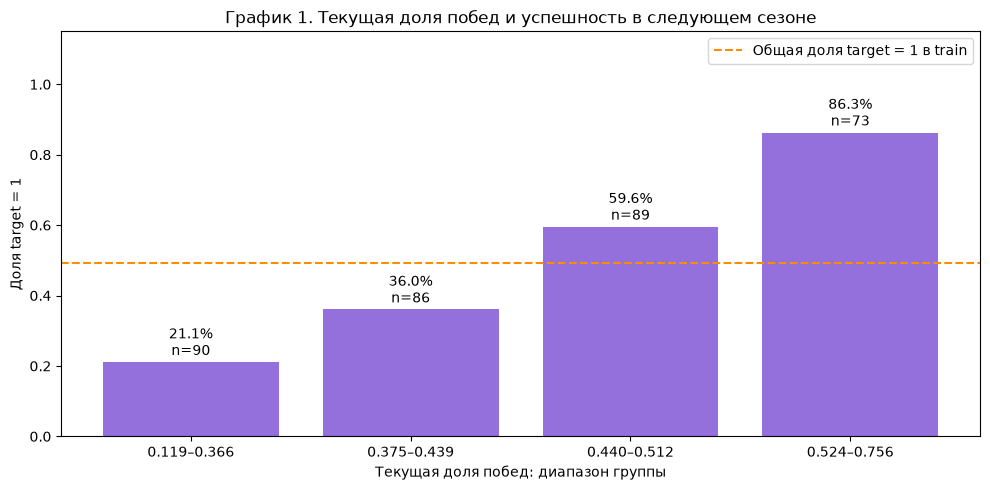

In [157]:
fig, ax = plt.subplots(figsize = (10, 5))
pos = list(range(len(win_summary)))

bars = ax.bar(pos, win_summary["success_rate"], color="mediumpurple")
ax.axhline(
    eda["target"].mean(),
    color="darkorange",
    linestyle="--",
    label="Общая доля target = 1 в train",
)

#общая доля, где target = 1
for bar, (_, row) in zip(bars, win_summary.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{row['success_rate']:.1%}\nn={int(row['n'])}",
        ha="center",
        fontsize=10,
    )

ax.set_xticks(pos)
ax.set_xticklabels([
    f"{row['win_rate_min']:.3f}–{row['win_rate_max']:.3f}"
    for _, row in win_summary.iterrows()
])

ax.set_ylim(0, 1.15)
ax.set_xlabel("Текущая доля побед: диапазон группы")
ax.set_ylabel("Доля target = 1")
ax.set_title("График 1. Текущая доля побед и успешность в следующем сезоне")
ax.legend()

plt.tight_layout()
plt.show()

Глядя на график, можно сказать, что гипотеза оправдывается и отвергать ее не нужно. То есть успех чаще всего сохраняется между сезонами

**Анализ для вопроса №2**

In [158]:
# медиана goal_diff для команды, которая принадлежит определенной группе
group_goal_median = (eda.groupby("win_group", observed=True)["goal_diff"].transform("median"))

low_label = "Не выше медианы группы"
high_label = "Выше медианы группы"

eda["goal_group"] = low_label
eda.loc[eda["goal_diff"] > group_goal_median,"goal_group"] = high_label

goal_summary = (
    eda.groupby(["win_group", "goal_group"], observed=True)
    .agg(
        n=("target", "size"),
        mean_win_rate=("win_rate", "mean"),
        mean_goal_diff=("goal_diff", "mean"),
        success_rate=("target", "mean"),
    )
)

print("Таблица 2. Разница голов и будущая успешность внутри групп win_rate")
display(goal_summary.round(3))

Таблица 2. Разница голов и будущая успешность внутри групп win_rate


n  mean_win_rate  mean_goal_diff  \
win_group      goal_group                                                  
(0.118, 0.366] Выше медианы группы     45          0.337         -30.867   
               Не выше медианы группы  45          0.273         -86.978   
(0.366, 0.439] Выше медианы группы     41          0.418           4.122   
               Не выше медианы группы  45          0.403         -22.333   
(0.439, 0.512] Выше медианы группы     44          0.487          36.023   
               Не выше медианы группы  45          0.472           8.956   
(0.512, 0.756] Выше медианы группы     36          0.593          74.556   
               Не выше медианы группы  37          0.549          40.081   

                                       success_rate  
win_group      goal_group                            
(0.118, 0.366] Выше медианы группы            0.244  
               Не выше медианы группы         0.178  
(0.366, 0.439] Выше медианы группы            0.366  
               Не выше медианы группы         0.356  
(0.439, 0.512] Выше медианы группы            0.705  
               Не выше медианы группы         0.489  
(0.512, 0.756] Выше медианы группы            0.917  
               Не выше медианы группы         0.811

Построим график

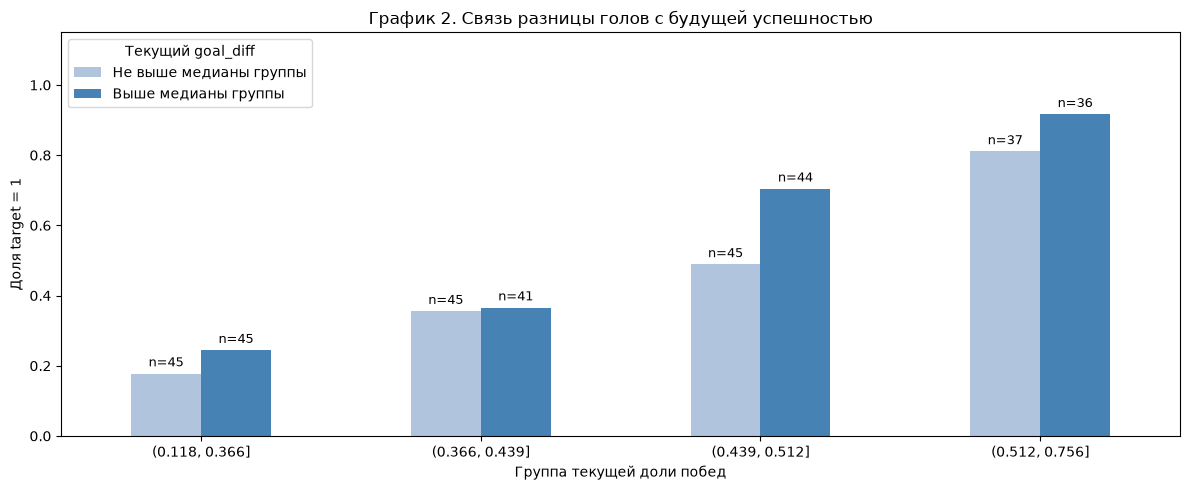

,"Разность долей, п.п."
win_group,
"(0.118, 0.366]",6.7
"(0.366, 0.439]",1.0
"(0.439, 0.512]",21.6
"(0.512, 0.756]",10.6


In [159]:
group_order = win_summary.index
goal_order = [low_label, high_label]

rates = (goal_summary["success_rate"].unstack("goal_group").reindex(index=group_order, columns=goal_order))
counts = (goal_summary["n"].unstack("goal_group").reindex(index=group_order, columns=goal_order))


ax = rates.plot.bar(figsize=(12, 5), color=["lightsteelblue", "steelblue"], rot=0)

for container, column in zip(ax.containers, rates.columns):
    labels = [
        f"n={int(value)}" if pd.notna(value) else ""
        for value in counts[column]
    ]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

ax.set_ylim(0, 1.15)
ax.set_xlabel("Группа текущей доли побед")
ax.set_ylabel("Доля target = 1")
ax.set_title("График 2. Связь разницы голов с будущей успешностью")
ax.legend(title="Текущий goal_diff")


plt.tight_layout()
plt.show()


# Разность долей в процентных пунктах
difference_pp = (100 * (rates[high_label] - rates[low_label])).rename("Разность долей, п.п.")
display(difference_pp.round(1).to_frame())

Рассмотрим конкретный пример

In [160]:
example = eda.loc[(eda["team"] == "Boston Bruins") & (eda["year"] == 1990)].copy()

assert len(example) == 1, "Ожидалась одна строка Boston Bruins за 1990 год"

print("Пример команды:")
display(
    example[
        ["team", "year", "win_rate", "goal_diff",
         "win_group", "goal_group", "target_year",
         "future_win_rate", "future_median", "target"]
    ]
)

row = example.iloc[0]
group_stats = win_summary.loc[row["win_group"]]

print(
    f"В {int(row['year'])} году текущая доля побед Boston Bruins "
    f"составляла {row['win_rate']:.3f}, "
    f"разница голов - {int(row['goal_diff'])}."
)

print(
    f"В {int(row['target_year'])} году доля побед составила "
    f"{row['future_win_rate']:.3f}, "
    f"медиана сезона - {row['future_median']:.3f}, "
    f"поэтому target = {int(row['target'])}."
)

print(
    f"В группе с сопоставимой текущей долей побед "
    f"успешность следующего сезона наблюдалась "
    f"в {group_stats['success_rate']:.1%} случаев "
    f"(n={int(group_stats['n'])})."
)

Пример команды:


,team,year,win_rate,goal_diff,win_group,goal_group,target_year,future_win_rate,future_median,target
0,Boston Bruins,1990,0.55,35,"(0.512, 0.756]",Не выше медианы группы,1991,0.45,0.444,1


В 1990 году текущая доля побед Boston Bruins составляла 0.550, разница голов - 35.
В 1991 году доля побед составила 0.450, медиана сезона - 0.444, поэтому target = 1.
В группе с сопоставимой текущей долей побед успешность следующего сезона наблюдалась в 86.3% случаев (n=73).


**Ответ 3.2:**

В ходе анализа исследовательских вопрос, можно выявить следующее:
1. Доля побед **влияет** на успешность. Начиная с группы с самой маленькой долей текущих побед в сезоне, доля target = 1 увеличивается с 21.1% до 86.3% в самой сильной с точки зрения побед группе.  
2. Более высокая разница голов также связан с будущей успешностью команды в группе с сопоставим win_rate. Однако, здесь связь не такая однозначная: тут различия колеблются от 1 п.п. до 21.6 п.п. Поэтому его можно рассмотреть как дополнительный признак. 
3. Также был проверен конкретный пример, который показывает, что общая успешность команды не гарантирует увеличение ее собственного результата. Винрейт снизился до 0.45, хотя все равно, target = 1.

## Раздел 4. Модели и эксперименты: 25 баллов

### 4.1. Постройте ориентиры

На train обучите простой константный baseline и оцените его на validation.
Отдельно используйте текущий `win_rate` как простую оценку для ранжирования
будущего класса. Посчитайте ROC-AUC обоих ориентиров и объясните,
какую планку задаёт каждый из них для обучаемой модели.

In [161]:
# 4.1. Ваш код
# Добавьте ячейки при необходимости.
X_train_baseline = train[["win_rate"]]
y_train = train["target"]


X_val_baseline = validation[["win_rate"]]
y_val = validation["target"]

assert y_train.nunique() == 2, "В train должны присутствовать оба класса"
assert y_val.nunique() == 2, "Для ROC-AUC в validation нужны оба класса"

#1. Константный бейзлайн
# Столбец win_rate передаём для интерфейса sklearn: DummyClassifier не использует его значения.
constant_baseline = DummyClassifier(strategy="prior")
constant_baseline.fit(X_train_baseline, y_train)

# Находим столбец вероятности именно класса 1
class_1_index = list(constant_baseline.classes_).index(1)
constant_scores = constant_baseline.predict_proba(
    X_val_baseline
)[:, class_1_index]
constant_auc = roc_auc_score(y_val, constant_scores)

# 2. Текущий win_rate как оценка для ранжирования
win_rate_scores = validation["win_rate"].to_numpy()
win_rate_auc = roc_auc_score(y_val, win_rate_scores)

# Сравнение ориентиров
baseline_results = pd.DataFrame({
    "Ориентир": [
        "Константный прогноз",
        "Текущий win_rate",
    ],
    "ROC-AUC на validation": [
        constant_auc,
        win_rate_auc,
    ]
})
print(f"Доля класса 1 в train: {y_train.mean():.4f}")
print(f"Константная вероятность класса 1: {constant_scores[0]:.4f}")
display(baseline_results.round(4))

Доля класса 1 в train: 0.4911
Константная вероятность класса 1: 0.4911


,Ориентир,ROC-AUC на validation
0,Константный прогноз,0.5000
1,Текущий win_rate,0.7568


**Ответ 4.1:**

На train был обучен константный baseline **DummyClassifier(strategy = 'prior')**. Так как метка бинарная (0 и 1), то он возвращает вероятность принадлежности к классу 1. Его ROC-AUC на валидации - _0.5_: одинаковые оценки не позволяют различать будущие успешные и неуспешные команды. В качестве оценки ранжирования этот ориентир не подойдет.  
Второй ориентир использует текущий винрейт. Его ROC_AUC превысил _0.75_, что логично в связи с анализом, совершенным в пункте 3. Здесь win_rate используется как оценка для ранжирования, а не вероятность принадлежности к классу с targert=1.

### 4.2. Постройте первую модель

Обучите логистическую регрессию. Самостоятельно выберите признаки и обоснуйте выбор.
Обработку пропусков и масштабирование включите в Pipeline и обучайте только на train.
Посчитайте ROC-AUC на validation и сравните с обоими ориентирами.
Объясните результат без использования test.

Разделим на признаки, выбор которых был обоснован ранее (это **win_rate** и **goal_diff**). Обучим логистическую регрессию и посчитаем ROC-AUC на валидации и сравним ориентиры.

In [162]:
# 4.2. Ваш код
# Добавьте ячейки при необходимости.
features = ["win_rate", "goal_diff"]

X_train = train[features]
y_train = train["target"]

X_val = validation[features]
y_val = validation["target"]

model = Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler()), ("classifier", LogisticRegression(C=1.0, solver="lbfgs", max_iter=1000, class_weight=None))])

model.fit(X_train, y_train)

# получаем вероятности класса 1 на validation
class_1_index = list(model.classes_).index(1)
val_probabilities = model.predict_proba(X_val)[:, class_1_index]

lr_auc = roc_auc_score(y_val, val_probabilities)
print(f"ROC-AUC логистической регрессии на validation: {lr_auc:.4f}")

ROC-AUC логистической регрессии на validation: 0.7720


Получили ROC-AUC выше, что радует. Сделаем наглядное сравнение:

In [163]:
comparison = pd.DataFrame({
    "Модель": [
        "Константный бейзлайн",
        "Текущий win_rate",
        "Логистическая регрессия",
    ],
    "ROC-AUC на validation": [
        constant_auc,
        win_rate_auc,
        lr_auc,
    ],
})

display(comparison.round(4))

,Модель,ROC-AUC на validation
0,Константный бейзлайн,0.5000
1,Текущий win_rate,0.7568
2,Логистическая регрессия,0.7720


**Ответ 4.2:**

Обучена логистическая регрессия c признаками **win_rate** и **goal_diff**, которые я выбрал ранее. В pipeline были включены заполнение пропусков (<u>SimpleImputer</u>) и масштабирование (<u>StandartScaler</u>) и обучены только на train. ROC-AUC на validation составил _0.7720_ против _0.5_ у константного бейзлайна и _0.7568_ у текущего win_rate. Таким образом, модель с двумя признаками немного улучшила ранжирование относительно простого ориентира. Однако результат одной временной выборки не доказывает устойчивость улучшения.

### 4.3. Проведите собственный эксперимент

Выберите одно осмысленное изменение: состав признаков, способ обработки данных,
параметры или другой алгоритм. До запуска запишите ожидаемый эффект и его причину.
Изменяйте одну понятную часть решения, сравните варианты на validation
и зафиксируйте выбор финальной модели до просмотра test.
Дополнительные эксперименты допустимы, но их количество само по себе не оценивается.

Проверю, сможет ли RandomForest обойти LogisticRegression по ROC-AUC. Предполагаю, что случайный лес сможет учесть нелинейности и взаимодействие между текущей долей побед и разницей голов. Состав признаков, разделение данных и предварительную обработку сохраняю. Для ограничения сложности буду использовать неглубокие деревья

In [164]:
# 4.3. Ваш код
# Добавьте ячейки при необходимости.
model_rf = clone(model)

model_rf.set_params(classifier=RandomForestClassifier(
    n_estimators=300, max_depth=3, min_samples_leaf=10, random_state=42, n_jobs=-1
))
features_rf = ["win_rate", "goal_diff"]
model_rf.fit(train[features_rf], train["target"])
class_1_index = list(model_rf.classes_).index(1)
rf_probabilities = model_rf.predict_proba(
    validation[features_rf]
)[:, class_1_index]

rf_auc = roc_auc_score(
    validation["target"],
    rf_probabilities,
)

In [165]:
experiment_results = pd.DataFrame({
    "Модель": [
        "Логистическая регрессия",
        "Случайный лес",
    ],
    "ROC-AUC на validation": [
        lr_auc,
        rf_auc,
    ],
})

display(experiment_results.round(4))
print(f"Изменение ROC-AUC: {rf_auc - lr_auc:+.4f}")

,Модель,ROC-AUC на validation
0,Логистическая регрессия,0.7720
1,Случайный лес,0.7457


Изменение ROC-AUC: -0.0263


**Ответ 4.3:**

Гипотеза о том, что RandomForest даст прирост в нашей метрике не может быть принята, так как ROC-AUC упал с 0.7720 до 0.7457. Использованы 300 деревьев, максимальная глубина 3, минимальный размер листа 10 и random_state=42. Для данного набора признаков ожидаемое улучшение получено не было и, можно сделать вывод, что случаный лес тут ранжирует изменения хуже. Возможная причина - недостаточный объем данных. 

Поэтому, выбор итоговой модели падает на <u>**LogisticRegression**</u> с признаками **win_rate** и **goal_diff**          и параметрами: С=1.0, solver = 'lbfgs', max_iter=1000, class_weight=None.

## Раздел 5. Итоговая оценка и анализ ошибок: 15 баллов

### 5.1. Проведите итоговую оценку

Зафиксируйте выбранную модель, признаки и параметры, затем один раз оцените её на test.
Покажите ROC-AUC, F1 и accuracy при пороге 0.5 для выбранной модели
и сопоставимых baseline. Объясните различия между метриками и сравните
результаты validation и test. После этого не меняйте выбранное решение.

In [166]:
# 5.1. Ваш код
# Добавьте ячейки при необходимости.
final_model = clone(model)
final_features = list(features)

print("Финальные признаки:", final_features)
print("Финальный Pipeline:")
display(final_model)
final_model.fit(train[final_features],train["target"])

constant_final = DummyClassifier(strategy="prior")
constant_final.fit(train[["win_rate"]], train["target"])

model_class_1 = list(final_model.classes_).index(1)
constant_class_1 = list(constant_final.classes_).index(1)

results = []
saved_scores = {}

for split_name, data in {
    "validation": validation,
    "test": test,
}.items():
    y_true = data["target"]

    assert y_true.nunique() == 2, (
        f"Для ROC-AUC нужны оба класса: {split_name}"
    )

    scores_by_model = {
        "Финальная модель": final_model.predict_proba(
            data[final_features]
        )[:, model_class_1],

        "Константный бейзлайн": constant_final.predict_proba(
            data[["win_rate"]]
        )[:, constant_class_1],

        "Текущий win_rate": data["win_rate"].to_numpy(),
    }

    saved_scores[split_name] = scores_by_model

    for model_name, scores in scores_by_model.items():
        # один и тот же порог для всех вариантов
        predictions = (scores >= 0.5).astype(int)

        results.append({
            "Выборка": split_name,
            "Модель": model_name,
            "ROC-AUC": roc_auc_score(y_true, scores),
            "F1": f1_score(y_true, predictions, zero_division=0),
            "Accuracy": accuracy_score(y_true, predictions),
        })

metrics_table = pd.DataFrame(results)
display(
    metrics_table
    .set_index(["Выборка", "Модель"])
    .round(4)
)

Финальные признаки: ['win_rate', 'goal_diff']
Финальный Pipeline:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto accou

ROC-AUC      F1  Accuracy
Выборка    Модель                                         
validation Финальная модель       0.7720  0.7500    0.7079
           Константный бейзлайн   0.5000  0.0000    0.5281
           Текущий win_rate       0.7568  0.7292    0.7079
test       Финальная модель       0.7596  0.7059    0.6629
           Константный бейзлайн   0.5000  0.0000    0.5281
           Текущий win_rate       0.7404  0.6522    0.6404

Обучили модель, зафиксировали значения метрик, а теперь посмотрим на таблицу полностью (5 строк)

In [167]:
test_comparison = test[
    ["team", "year", "target_year",
     "future_win_rate", "future_median", "target"]
].copy()

test_comparison = test_comparison.rename(
    columns={"target": "actual_target"}
)

test_comparison["predicted_probability"] = (
    saved_scores["test"]["Финальная модель"]
)

test_comparison["predicted_target"] = (
    test_comparison["predicted_probability"] >= 0.5
).astype(int)

test_comparison["correct"] = (
    test_comparison["actual_target"]
    == test_comparison["predicted_target"]
)

display(test_comparison.head())

,team,year,target_year,future_win_rate,future_median,actual_target,predicted_probability,predicted_target,correct
462,Anaheim Ducks,2008,2009,0.476,0.488,0,0.634902,1,False
463,Atlanta Thrashers,2008,2009,0.427,0.488,0,0.403406,0,True
464,Boston Bruins,2008,2009,0.476,0.488,0,0.909246,1,False
465,Buffalo Sabres,2008,2009,0.549,0.488,1,0.637896,1,True
466,Calgary Flames,2008,2009,0.488,0.488,0,0.710051,1,False


**Ответ 5.1:**

На тесте финальная модель получила ROC-AUC = 0.7596, F1 = 0.7059 и accuracy = 0.6629 при пороге 0.5. Она превзошла оба ориентира по всем 3-м метрикам. ROC-AUC характеризует ранжирование наблюдений без выбора одного порога. F1 отражает баланс precision и recall класса 1, а accuracy - долю правильных ответов при пороге 0.5. У константного бейзлайна F1 равен нулю, поскольку он всем предсказывает класс 0. По сравнению с текущим win_rate прирост составил 0.0192 ROC-AUC, 0.0537 F1 и 2.25 процентного пункта accuracy. Таким образом, на тестовом периоде модель показала небольшое улучшение относительно бейзлайна.

По сравнению с валидацией качество снизилось ROC-AUC - с 0.7720 до 0.7596, F1 - с 0.7500 до 0.7059, Accuracy - с 0.7079 до 0.6629.

Результаты поддерживают выбор финальной модели (то есть логистичекской регрессии), но преимущество оценено на одном тестовом периоде и его статистическая устойчивость не проверялась. После итоговой оценки признаки, параметры и порог модели не изменяются.

### 5.2. Разберите ошибки

Выберите от трёх до пяти ошибок финальной модели по явно указанному принципу.
Это могут быть наиболее уверенные ошибки, отдельный тип ошибки или другой
обоснованный набор. Покажите идентификаторы строк, вероятности и значения,
необходимые для анализа. Найдите общие черты и различия; отделите факты
из таблицы от гипотез и назовите данные, нужные для проверки одной гипотезы.

Сделаем более подробную аналитику именно с этими ошибочно предсказанными строчками

In [ ]:
selected_errors = test_comparison.loc[[496, 484, 512, 517, 495]].copy()

# добавляем текущие показатели, которые были доступны модели
selected_errors = selected_errors.merge(
    test[["team", "year", "win_rate", "goal_diff"]],
    on=["team", "year"],
    how="left",
    validate="one_to_one"
)

selected_errors["error_type"] = selected_errors["actual_target"].map({
    0: "Ложноположительная",
    1: "Ложноотрицательная",
})

# Разница будущего результата и будущей медианы
selected_errors["future_margin"] = (selected_errors["future_win_rate"] - selected_errors["future_median"])
selected_errors["win_rate_change"] = (selected_errors["future_win_rate"] - selected_errors["win_rate"])

display(
    selected_errors[
        ["team", "year", "target_year", "win_rate", "goal_diff",
         "future_win_rate", "future_median", "future_margin",
         "win_rate_change", "predicted_probability",
         "actual_target", "predicted_target", "error_type"]
    ].round(4)
)

,team,year,target_year,win_rate,goal_diff,future_win_rate,future_median,future_margin,win_rate_change,predicted_probability,actual_target,predicted_target,error_type
0,Calgary Flames,2009,2010,0.488,-6,0.500,0.524,-0.024,0.012,0.5589,0,1,Ложноположительная
1,Phoenix Coyotes,2008,2009,0.439,-44,0.610,0.488,0.122,0.171,0.3689,1,0,Ложноотрицательная
2,Ottawa Senators,2009,2010,0.537,-13,0.390,0.524,-0.134,-0.147,0.6254,0,1,Ложноположительная
3,St. Louis Blues,2009,2010,0.488,2,0.463,0.524,-0.061,-0.025,0.5805,0,1,Ложноположительная
4,Buffalo Sabres,2009,2010,0.549,28,0.524,0.524,0.000,-0.025,0.7412,0,1,Ложноположительная


**Ответ 5.2:**

Для анализа ошибок были выбраны 5 случайных строчек из набора данных, которые содержат ложную target. 4 из них являются FP(ложноположительные), а одна - FN (ложноотрицательная). Ошибки отличаются по уверенности и величине отклонения. Возможная гипотеза состоит в том, что часть ошибок связана с изменениями состава или доступности топ-игроков, которые не отражены в текущих данных. Для проверки потребуются данные о переходах игроков, травмах и пропущенных матчах с датами событий. Проанализируем каждую из команд по отдельности:
1. **Phoenix Coyotes** показали наиболее заметный рост среди выбранных команд: доля побед увеличилась с 0.439 до 0.610 - на 17,1 процентного пункта. Текущая разница голов составляла "−44", а модель оценила вероятность будущего успеха лишь в 36.9%. Прогноз оказался ошибочным: в следующем сезоне команда превысила медиану на 12.2 п.п.
2. **Ottawa Senators** демонстрируют противоположный случай: доля побед снизилась с 0.537 до 0.390 - на 14.7 п.п. Модель дала вероятность успеха 62.5%, однако команда оказалась заметно ниже будущей медианы. Эти два примера показывают ошибки при существенном изменении результатов между сезонами.
3. **Calgary Flames** немного улучшили долю побед — с 0.488 до 0.500, но всё равно остались ниже будущей медианы 0.524. Следовательно, улучшение собственного результата не обязательно приводит к target = 1 (как уже было упомянуто ранее).
4. У **St. Louis Blues** и **Buffalo Sabres** доля побед снизилась одинаково — на 2.5 п.п. Однако положение относительно будущей медианы различалось: **St. Louis** оказались ниже неё на 6.1 п.п., а Buffalo — ровно на границе. При этом Buffalo получили наиболее высокую вероятность успеха среди выбранных ошибок — 74.1%. 

## Раздел 6. Выводы и воспроизводимость: 5 баллов

### 6.1. Сформулируйте выводы

Сформулируйте основные выводы и ограничения работы со ссылками на свои графики,
строки и метрики. Опишите минимум два решения, которые вы изменили
или подтвердили после получения результатов. Назовите одно улучшение,
которое вы сознательно не стали выполнять, и объясните причину.
Убедитесь, что последовательность работы и финальные параметры можно воспроизвести.

**Ответ 6.1:**

##### Основные выводы по анализу, проведенному в ходе выполнения отоборочного задания: 
1. В ходе выгрузки и анализа данных, основным показателем, который мы предсказывали будет ли команда успешна в следующем сезоне или же нет, опираясь на данные в текущем сезоне.
2. Основными признаками были **win_rate** (отношение числа побед ко всем матчам), а также **goal_diff** (разница забитых и пропущенных голов). В ходе анализа, было выявлено, что эти признаки кореллируют с результатом и их нужно включить в обучающую выборку. 
3. В качестве модели был обучен константный бейзлайн, а также составлен ручной ориентир. Далее была проведена оценка между ними, где выявилось, что ручной метод выдает результат лучше. Далее была обучена логистическая регрессия с параметрами _С=1.0_, _solver = 'lbfgs'_, _max_iter=1000_, _class_weight=None_, которая получила лучшее значение по выбранной метрике ROC-AUC. В качестве альтернативы был выбран случайный лес с параметрами _n_estimators=300_, _max_depth=3_, _min_samples_leaf=10_, _random_state=42_, _n_jobs=-1_. RandomForest не дал прироста, а наоборот даже немного ухудшил результат на валидации. Возможной причиной этого может быть нехватка данных на тестовом наборе. 
4. В качестве финальной модели была выбрана логистическая регрессия с теми же параметрами. Итоги по метрикам продемонстрированы в итогах в пункте 5.1. (ROC-AUC 0.7596 против 0.7404)

<u>Улучшение, которое осознано не было выполнено:</u>

В качестве альтернативы для случайного леса, я также протестировал логистическую регрессию, но уже на других признаках: разница голов была разделена на 2 столбца - пропущенные и забитые мячи. Остальные параметры внутри модели остались неизменными и это показало результат незначительно лучше - прирост составил 0.0025 к метрике ROC-AUC. Данное решение не пошло в альтернативу и не стало финальным, так как я решил, что использование другого алгоритма протестирует мою гипотезу о работе случайного леса с нелинейностями, что и было продемонстрировано - гипотеза была отвергнута.

Последовательность работы и финальные параметры можно воспроизвести

## Приложение:

Дополнительный эксперимент заменяет goal_diff двумя признаками: goals_for и goals_against. Это позволяет независимо оценивать вклад забитых и пропущенных голов. Остальные настройки и предварительная обработка сохраняются. Сравнение проводится только на validation; выбранная финальная модель не изменяется.

In [171]:
new_features = ["win_rate", "goals_for", "goals_against"]
new_model = clone(final_model)

new_model.fit(train[new_features], train["target"])

class_1_index = list(new_model.classes_).index(1)

new_probabilities = new_model.predict_proba(validation[new_features])[:, class_1_index]

new_auc = roc_auc_score(validation["target"],new_probabilities)

original_class_1 = list(final_model.classes_).index(1)

original_probabilities = final_model.predict_proba(
    validation[final_features]
)[:, original_class_1]

original_auc = roc_auc_score(
    validation["target"],
    original_probabilities,
)

new_results = pd.DataFrame({
    "Признаки": [
        ", ".join(final_features),
        ", ".join(new_features),
    ],
    "ROC-AUC на validation": [
        original_auc,
        new_auc,
    ],
})

display(new_results.round(4))
print(f"Изменение ROC-AUC: {new_auc - original_auc:+.4f}")

,Признаки,ROC-AUC на validation
0,"win_rate, goal_diff",0.7720
1,"win_rate, goals_for, goals_against",0.7746


Изменение ROC-AUC: +0.0025
